RSP tutorial
This is a short tutorial covering:
1. Data access with Butler and TAP service
    * Catalogs
    * Images
2. Image processing tools:
    * Characterization
    * Detection
    * Injection
    * Forced photometry
    * DIA photometry 

# Data access with Butler and TAP service

The images for Rubin's Data Preview 0 and 1 are available via both the data butler and the TAP (Table Access Protocol) service.

The [Butler](https://pipelines.lsst.io/modules/lsst.daf.butler/index.html) is Rubin’s complete data repository: it contains all images, calibrations, intermediate and final catalogs, PSFs, pipeline outputs, and any user-generated products.

TAP exposes only a curated, tabular subset of those data:

* large final catalogs,
* stable,
* well-documented,
* designed for statistical analysis and fast querying.

TAP is fed from the Butler, but it does not include everything the Butler contains.

* [Butler](https://pipelines.lsst.io/modules/lsst.daf.butler/index.html) Use of the butler to query and retrieve images, and is generally the recommended way to access DP0 images while working within the Notebook Aspect of the Rubin Science Platform, especially if any image reprocessing is being done.
The Butler is the LSST Science Pipelines interface for managing, reading, and writing datasets.

* However, image access via the TAP service is also possible. It is how images are accessed via the Portal and API Aspects of the Rubin Science Platform. It is an IVOA-standards-compliant interface that is based on the ObsCore and DataLink standards that are used for this purpose by many other astronomical archives.

### Butler 
With Butler, one can access collections. The are references to different type of datasets that are references to any raw, intermediate and final product of LSST. 


    [Collections](https://pipelines.lsst.io/v/weekly/modules/lsst.daf.butler/organizing.html#collections) are lightweight groups of self-consistent datasets such as raw images, calibration files, reference catalogs, and the outputs of a processing run. For the purposes of accessing the DP0.2 data, we will use the 2.2i/runs/DP0.2 collection. Here, '2.2i' refers to the imSim run that was used to generated the simulated data and 'runs' refers to the fact that it is processed data.


In [1]:
from lsst.daf.butler import Butler

In [2]:
butler = Butler('dp02', collections='2.2i/runs/DP0.2')
#butler = Butler("dp1", collections="LSSTComCam/DP1")

Collection's dataset types can be retrived as follows.

In [3]:
dataset_types = list(butler.registry.queryDatasetTypes(expression=...))
print(f"{'Dataset Type':40} {'Dimensions':60} {'Storage Class':20}")
print("-" * 85)
for ds in dataset_types[:10]:
    name = ds.name
    dims = ", ".join(ds.dimensions.names)
    sc   = ds.storageClass.name
    print(f"{name:40} {dims:60} {sc:20}")

Dataset Type                             Dimensions                                                   Storage Class       
-------------------------------------------------------------------------------------
skyMap                                   skymap                                                       SkyMap              
cal_ref_cat_2_2                          htm7                                                         SimpleCatalog       
raw                                      band, instrument, detector, physical_filter, exposure        Exposure            
camera                                   instrument                                                   Camera              
deepCoadd_det_schema                                                                                  SourceCatalog       
deepCoadd_calexp                         band, skymap, tract, patch                                   ExposureF           
deepCoadd_calexp_background              band, skymap

In [4]:
#butler = Butler('dp02', collections='2.2i/runs/DP0.2')
butler = Butler("dp1", collections="LSSTComCam/DP1")

In [5]:
dataset_types = list(butler.registry.queryDatasetTypes(expression=...))
print(f"{'Dataset Type':40} {'Dimensions':60} {'Storage Class':20}")
print("-" * 85)
for ds in dataset_types:
    name = ds.name
    if "visit" in name:
        dims = ", ".join(ds.dimensions.names)
        sc   = ds.storageClass.name
        print(f"{name:40} {dims:60} {sc:20}")

Dataset Type                             Dimensions                                                   Storage Class       
-------------------------------------------------------------------------------------
visit_detector_table                     instrument                                                   ArrowAstropy        
visit_image                              band, instrument, day_obs, detector, physical_filter, visit  ExposureF           
visit_table                              instrument                                                   ArrowAstropy        
visit_image_background                   band, instrument, day_obs, detector, physical_filter, visit  Background          
visit_summary                            band, instrument, day_obs, physical_filter, visit            ExposureCatalog     


### TAP
schema: name of a group of related tables

#### Schemas (Data Previews and others)
From tap_schema.schema we can get the available schemas 

In [6]:
from lsst.rsp import get_tap_service, retrieve_query
service = get_tap_service("tap")
query = 'SELECT * FROM tap_schema.schemas'
results_table = service.search(query).to_table()
results_table

schema_name,utype,description,schema_index
str64,str512,str512,int32
dp02_dc2_catalogs,,"Data Preview 0.2 contains the image and catalog products of the Rubin Science Pipelines v23 processing of the DESC Data Challenge 2 simulation, which covered 300 square degrees of the wide-fast-deep LSST survey region over 5 years.",2
dp1,,"Data Preview 1 contains image and catalog products from the Rubin Science Pipelines v29 processing of observations obtained with the LSST Commissioning Camera of seven ~1 square degree fields, over seven weeks in late 2024.",0
ivoa,,ObsCore v1.1 attributes in ObsTAP realization,1
tap_schema,,A TAP-standard-mandated schema to describe tablesets in a TAP 1.1 service,100000


#### Tables
For each data preview we have in common the main table names where

* Identification of individuals:
    * Source: refers to one detection of an Object
    * Object: refers to the unique object. It can have many related sources)
    Many sources of the same object creates a light curve of an Object and its foot-print


* Meta data of observations
    * Ccdvisit: refers to one ccd of each visit
    * Visit: refers to the unique pointing
    There are 189 CCDs per visit

* Measurements:
    * DIA:  transient-object detections 
    * Forced: Forced photometry

* CoadddPatches

But since dp0.2 is a simulation and dp1 is real data, they have some differents tables like TruthSummary, SSSObject that are subproducts of extra processment/analysis run for certain science objective.


In [7]:
query = "SELECT * FROM tap_schema.tables " \
        "WHERE tap_schema.tables.schema_name = 'dp02_dc2_catalogs'" \
        "ORDER BY table_index ASC"
results_table = service.search(query).to_table()
results_table

schema_name,table_name,table_type,utype,description,table_index
str512,str64,str8,str512,str512,int32
dp02_dc2_catalogs,dp02_dc2_catalogs.Object,table,,Properties of the astronomical objects detected and measured on the deep coadded images.,10
dp02_dc2_catalogs,dp02_dc2_catalogs.Source,table,,"Properties of detections on the single-epoch visit images, performed independently of the Object detections on coadded images.",20
dp02_dc2_catalogs,dp02_dc2_catalogs.ForcedSource,table,,"Forced-photometry measurements on individual single-epoch visit images and difference images, based on and linked to the entries in the Object table. Point-source PSF photometry is performed, based on coordinates from a reference band chosen for each Object and reported in the Object.refBand column.",30
dp02_dc2_catalogs,dp02_dc2_catalogs.DiaObject,table,,Properties of time-varying astronomical objects based on association of data from one or more spatially-related DiaSource detections on individual single-epoch difference images.,40
dp02_dc2_catalogs,dp02_dc2_catalogs.DiaSource,table,,Properties of transient-object detections on the single-epoch difference images.,50
dp02_dc2_catalogs,dp02_dc2_catalogs.ForcedSourceOnDiaObject,table,,"Point-source forced-photometry measurements on individual single-epoch visit images and difference images, based on and linked to the entries in the DiaObject table.",60
dp02_dc2_catalogs,dp02_dc2_catalogs.ObsCore,table,,Observation metadata in the ObsTAP relational realization of the IVOA ObsCore data model,65
dp02_dc2_catalogs,dp02_dc2_catalogs.Visit,table,,"Metadata about the pointings of the DC2 simulated survey, largely associated with the boresight of the entire focal plane.",70
dp02_dc2_catalogs,dp02_dc2_catalogs.CcdVisit,table,,Metadata about the 189 individual CCD images for each Visit in the DC2 simulated survey.,80


In [8]:
query = "SELECT * FROM tap_schema.tables " \
        "WHERE tap_schema.tables.schema_name = 'dp1'" \
        "ORDER BY table_index ASC"
results_table = service.search(query).to_table()
results_table

schema_name,table_name,table_type,utype,description,table_index
str512,str64,str8,str512,str512,int32
dp1,dp1.Object,table,,Descriptions of static astronomical objects (or the static aspects of variable and slowly-moving objects) detected and measured on coadds.,10
dp1,dp1.Source,table,,"Properties of detections on the single-epoch visit images, performed independently of the Object detections on coadded images.",20
dp1,dp1.ForcedSource,table,,"Forced-photometry measurements on individual single-epoch visit images and difference images, based on and linked to the entries in the Object table. Point-source PSF photometry is performed, based on coordinates from a reference band chosen for each Object and reported in the Object.refBand column.",30
dp1,dp1.DiaObject,table,,Properties of time-varying astronomical objects based on association of data from one or more spatially-related DiaSource detections on individual single-epoch difference images.,40
dp1,dp1.DiaSource,table,,Properties of transient-object detections on the single-epoch difference images.,50
dp1,dp1.ForcedSourceOnDiaObject,table,,"Point-source forced-photometry measurements on individual single-epoch visit images and difference images, based on and linked to the entries in the DiaObject table.",60
dp1,dp1.CoaddPatches,table,,Static information about the subset of tracts and patches from the standard LSST skymap that apply to coadds in these catalogs,70
dp1,dp1.Visit,table,,"Metadata about the pointings of the telescope, largely associated with the boresight of the LSSTComCam focal plane as a whole.",80
dp1,dp1.CcdVisit,table,,Metadata about the nine individual CCD images for each Visit in the DP1 LSSTComCam dataset.,90


##### Columns (Tables content)
Inspect columns of any table as follows.

In [9]:
query = "SELECT column_name, datatype, description, unit " \
        "FROM tap_schema.columns " \
        "WHERE table_name = 'dp02_dc2_catalogs.Source'"
results_dp0 = service.search(query).to_table()
results_dp0

column_name,datatype,description,unit
str64,str64,str512,str64
ap03Flux,double,Flux within 3.0-pixel aperture,nJy
ap03Flux_flag,boolean,General Failure Flag,
ap03FluxErr,double,Flux uncertainty within 3.0-pixel aperture,nJy
ap06Flux,double,Flux within 6.0-pixel aperture,nJy
ap06Flux_flag,boolean,General Failure Flag,
ap06FluxErr,double,Flux uncertainty within 6.0-pixel aperture,nJy
ap09Flux,double,Flux within 9.0-pixel aperture,nJy
ap09Flux_flag,boolean,General Failure Flag,
ap09FluxErr,double,Flux uncertainty within 9.0-pixel aperture,nJy


In [10]:
query = "SELECT column_name, datatype, description, unit " \
        "FROM tap_schema.columns " \
        "WHERE table_name = 'dp1.ForcedSource'"
# results = service.search(query)
results_dp1 = service.search(query).to_table()
results_dp1

column_name,datatype,description,unit
str64,str64,str512,str64
band,char,Abstract filter that is not associated with a particular instrument,
coord_dec,double,Fiducial ICRS Declination of centroid used for database indexing,deg
coord_ra,double,Fiducial ICRS Right Ascension of centroid used for database indexing,deg
detector,long,Id of the detector where this source was measured.,
diff_PixelFlags_nodataCenter,boolean,Source center is outside usable region on image difference (masked NO_DATA),
invalidPsfFlag,boolean,Source has an invalid PSF.,
objectId,long,Unique Object ID. Primary Key of the Object Table,
parentObjectId,long,Unique ObjectId of the parent of the ObjectId in context of the deblender.,
patch,long,Skymap patch ID,


In [11]:
search_string = 'Id'
for cname in results_dp0['column_name']:
    if cname.find(search_string) > -1:
        print(cname)

ccdVisitId
parentSourceId
sourceId


In [12]:
search_string = 'Id'
for cname in results_dp1['column_name']:
    if cname.find(search_string) > -1:
        print(cname)

objectId
parentObjectId


**Note**: names of columns are different in each Data Preview.

#### Summary: 
* TAP → fast queries on large, clean catalogs (DP0/DP1, ObsCore).
* Butler → access to images, PSFs, masks, and per-visit catalogs for detailed analysis.

#### Recommended workflow:

Use TAP to select targets (query objects and retrieve exposure/data IDs) → use Butler to load the corresponding data products (images, PSFs, catalogs), process them if needed, and perform scientific analysis.

## Load images

To load an image where a particular source is contained. We will obtain needed data references of the source with TAP and then load them with Butler:
1. Find individual exposure dataId: "detector" and "visit" with TAP catalogs: Run cone search to obtain sources within a region and got the
2. Choose an image and visualize sources and region
3. Obtain image data:
    * from TAP catalogs
    * compute characteristics with RSP tools

First, from Butler we can know what dataset types are available and which parameters identifies one item as "dimensions" (as shown in the upper section)



1) Find individual exposure dataId: "detector" and "visit" with TAP catalogs
2) Load image with Butler
3) Plot image and cone search sources





In [13]:
butler = Butler('dp02', collections='2.2i/runs/DP0.2')

datasetType = "calexp"   
print(butler.registry.getDatasetType(datasetType)) 
datasetType = "deepCoadd"   
print(butler.registry.getDatasetType(datasetType)) 
datasetType = "objectTable"   
print(butler.registry.getDatasetType(datasetType)) 
datasetType = "goodSeeingDiff_differenceExp"   
print(butler.registry.getDatasetType(datasetType))

DatasetType('calexp', {band, instrument, detector, physical_filter, visit_system, visit}, ExposureF)
DatasetType('deepCoadd', {band, skymap, tract, patch}, ExposureF)
DatasetType('objectTable', {skymap, tract, patch}, DataFrame)
DatasetType('goodSeeingDiff_differenceExp', {band, instrument, detector, physical_filter, visit_system, visit}, ExposureF)


In [14]:
butler = Butler("dp1", collections="LSSTComCam/DP1")

datasetType = "visit_image"   
print(butler.registry.getDatasetType(datasetType)) 
datasetType = "deep_coadd"   
print(butler.registry.getDatasetType(datasetType))  
datasetType = "difference_image"   
print(butler.registry.getDatasetType(datasetType))

DatasetType('visit_image', {band, instrument, day_obs, detector, physical_filter, visit}, ExposureF)
DatasetType('deep_coadd', {band, skymap, tract, patch}, ExposureF)
DatasetType('difference_image', {band, instrument, day_obs, detector, physical_filter, visit}, ExposureF)


### Cone search
Define collection and cone search region

In [15]:
butler = Butler('dp02', collections='2.2i/runs/DP0.2')
schema = "dp02_dc2_catalogs"
table = "Source"

center_ra = 62
center_dec = -37
radius = 0.01

Run job to query sources within a circle region defined above

In [16]:
from lsst.rsp import get_tap_service, retrieve_query
service = get_tap_service("tap")
query = "SELECT coord_ra, coord_dec, visit, detector, psfFlux, band "\
        f"FROM {schema}.{table} "\
        "WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), "\
        f"CIRCLE('ICRS', {center_ra}, {center_dec}, {radius})) = 1 "\
        "AND detect_isPrimary = 1"
print(query)
job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
results = job.fetch_result().to_table().to_pandas()
job.delete()
results

SELECT coord_ra, coord_dec, visit, detector, psfFlux, band FROM dp02_dc2_catalogs.Source WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), CIRCLE('ICRS', 62, -37, 0.01)) = 1 AND detect_isPrimary = 1
Job phase is COMPLETED


,coord_ra,coord_dec,visit,detector,psfFlux,band
0,61.996890,-36.997878,939919,28,3089.720277,z
1,62.000288,-37.002584,939919,28,7387.986667,z
2,62.002739,-37.008272,939919,28,37936.829609,z
3,61.999850,-36.998843,939919,28,18771.047430,z
4,61.997307,-36.995684,939919,28,4617.653417,z
...,...,...,...,...,...,...
3415,62.011091,-36.996162,958700,9,1048.389284,r
3416,62.000031,-36.998393,958700,9,2795.961724,r
3417,61.997330,-36.995744,1168284,44,3089.059377,u
3418,62.008416,-37.006442,1168284,44,2155.507552,u


### Load image

Now we select and load a random one calexp (individual exposure) univocally defined by its detector and visit

In [17]:
source_data = results.iloc[150]
datasetType = 'calexp'
dataId = {'visit': source_data["visit"], 'detector': source_data["detector"]}
calexp = butler.get(datasetType, dataId=dataId)

### Plot
Image, sources and cutout

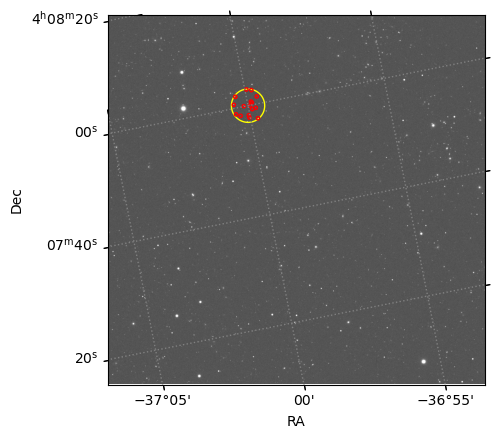

In [18]:
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval, ImageNormalize
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes import SphericalCircle

calexp_wcs = calexp.getWcs()   # other way: calexp_wcs = butler.get('calexp.wcs', **dataId)
fig = plt.figure()
ax = plt.subplot(projection=WCS(calexp_wcs.getFitsMetadata()))

im = plt.imshow(calexp.image.array, cmap='gray', vmin=-200.0, vmax=400,
                 origin='lower')
plt.grid(color='gray', ls=':', lw=1)

region = SphericalCircle((center_ra, center_dec) * u.deg,radius * u.deg, edgecolor='yellow', facecolor='none',  transform=ax.get_transform('world') )
plt.gca().add_patch(region)

contained_sources = results[(results["visit"]==dataId["visit"]) & (results["detector"]==dataId["detector"])][["coord_ra","coord_dec"]].values
for ra, dec in contained_sources:
    region = SphericalCircle((ra, dec) * u.deg, 0.001 * u.deg, edgecolor='red', facecolor='none', transform=ax.get_transform('world') )
    plt.gca().add_patch(region)

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
plt.show()


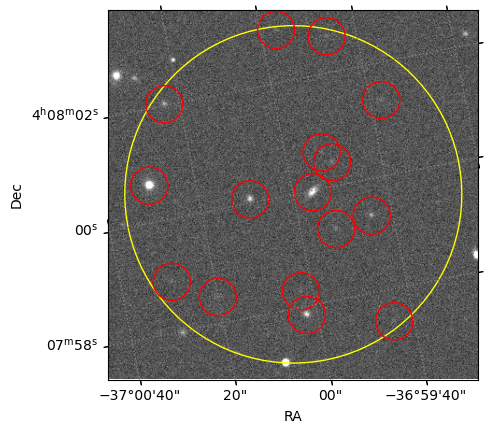

In [19]:
import lsst.geom as geom 

# Fix the cutout in the cone search
cutout_deg = radius*2.2
pixel_scale = calexp_wcs.getPixelScale().asDegrees()  
cutoutSideLength = int(cutout_deg / pixel_scale)
radec = geom.SpherePoint(center_ra, center_dec, geom.degrees)
cutoutSize = geom.Extent2I(cutoutSideLength, cutoutSideLength)    

# Create cutout
xy = geom.PointI(calexp_wcs.skyToPixel(radec))
bbox = geom.BoxI(xy - cutoutSize // 2, cutoutSize)
parameters = {'bbox': bbox}
cutout= butler.get('calexp', parameters=parameters, **dataId)   # OR cutout = calexp.getCutout(radec, cutoutSize)
cutout_wcs = cutout.getWcs()

# Plot cutout
fig = plt.figure()
ax = plt.subplot(projection=WCS(cutout_wcs.getFitsMetadata()))
ax.imshow(
    cutout.image.array,
    cmap='gray',
    origin='lower',
    vmin=-200.0, 
    vmax=400,
    extent=[
        bbox.getMinX(), bbox.getMaxX(),
        bbox.getMinY(), bbox.getMaxY()
    ]
)

# Mark cone search and sources
region = SphericalCircle((center_ra, center_dec)*u.deg ,radius * u.deg, edgecolor='yellow', facecolor='none', transform=ax.get_transform('world'))
plt.gca().add_patch(region)

contained_sources = results[(results["visit"]==dataId["visit"]) & (results["detector"]==dataId["detector"])][["coord_ra","coord_dec"]].values
for ra, dec in contained_sources:
    region = SphericalCircle((ra, dec) * u.deg,cutout_deg * 0.05 * u.deg, edgecolor='red', facecolor='none', transform=ax.get_transform('world') )
    plt.gca().add_patch(region)

plt.grid(color='gray', ls=':', lw=1)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
plt.show()

Try it in DP1

In [20]:
butler = Butler('dp02', collections='2.2i/runs/DP0.2')
schema = "dp1"
table = "Source"
center_ra, center_dec = 53.13, -28.10

radius = 0.01

In [21]:
from lsst.rsp import get_tap_service, retrieve_query
service = get_tap_service("tap")
query = "SELECT coord_ra, coord_dec, visit, detector, psfFlux, band "\
        f"FROM {schema}.{table} "\
        "WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), "\
        f"CIRCLE('ICRS', {center_ra}, {center_dec}, {radius})) = 1 "
print(query)
job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
results_dp1 = job.fetch_result().to_table().to_pandas()
job.delete()
results_dp1

SELECT coord_ra, coord_dec, visit, detector, psfFlux, band FROM dp1.Source WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), CIRCLE('ICRS', 53.13, -28.1, 0.01)) = 1 
Job phase is COMPLETED


,coord_ra,coord_dec,visit,detector,psfFlux,band
0,53.127603,-28.101784,2024110800268,3,713.609530,g
1,53.133360,-28.097691,2024110800268,3,532.341944,g
2,53.131612,-28.103201,2024110800268,3,566.496463,g
3,53.133066,-28.103233,2024110800268,3,1378.901349,g
4,53.128228,-28.109364,2024110800268,3,10544.809784,g
...,...,...,...,...,...,...
10795,53.132949,-28.103187,2024120900331,3,3261.144464,z
10796,53.138856,-28.098708,2024120900331,3,5509.142370,z
10797,53.126239,-28.103481,2024120900331,3,21605.034687,z
10798,53.128868,-28.104878,2024120900331,3,5290.678547,z


In [22]:
butler = Butler("dp1", collections="LSSTComCam/DP1")
source_data = results_dp1.iloc[150]
datasetType = 'visit_image'
dataId = {'visit': source_data["visit"], 'detector': source_data["detector"]}
calexp = butler.get(datasetType, dataId=dataId)

We may want to know characteristics of the image or observational conditions
## Image metadata

### From TAP service


In [23]:
query = "SELECT column_name, datatype, description, unit " \
        "FROM tap_schema.columns " \
        "WHERE table_name = 'dp02_dc2_catalogs.Visit'"
results_dp0 = service.search(query).to_table()
results_dp0

column_name,datatype,description,unit
str64,str64,str512,str64
airmass,double,Airmass of the observed line of sight.,
altitude,double,Altitude of focal plane center at the middle of the exposure.,deg
azimuth,double,Azimuth of focal plane center at the middle of the exposure.,deg
band,char,Name of the band used to take the exposure where this source was measured. Abstract filter that is not associated with a particular instrument.,
decl,double,Declination of focal plane center,deg
expMidpt,char,"Midpoint time for exposure at the fiducial center of the focal plane array. TAI, accurate to 10ms.",
expMidptMJD,double,"Midpoint time for exposure at the fiducial center of the focal plane array in MJD. TAI, accurate to 10ms.",d
expTime,double,"Spatially-averaged duration of exposure, accurate to 10ms.",s
obsStart,char,"Start time of the exposure at the fiducial center of the focal plane array, TAI, accurate to 10ms.",


In [24]:
query = "SELECT column_name, datatype, description, unit " \
        "FROM tap_schema.columns " \
        "WHERE table_name = 'dp02_dc2_catalogs.CcdVisit'"
results_dp0 = service.search(query).to_table()
results_dp0

column_name,datatype,description,unit
str64,str64,str512,str64
band,char,Name of the band used to take the exposure where this source was measured. Abstract filter that is not associated with a particular instrument.,
ccdVisitId,long,Primary key (unique identifier).,
darkTime,double,"Average dark current accumulation time, accurate to 10ms.",s
decl,double,Declination of CCD center.,deg
detector,long,Detector ID. A detector associated with a particular instrument (not an observation of that detector),
expMidpt,char,"Midpoint for exposure. TAI, accurate to 10ms.",
expMidptMJD,double,"Midpoint for exposure in MJD. TAI, accurate to 10ms.",d
expTime,double,"Spatially-averaged duration of exposure, accurate to 10ms.",s
llcdec,double,Declination of lower left corner.,deg


In [25]:
from lsst.rsp import get_tap_service, retrieve_query
service = get_tap_service("tap")
schema ="dp1"
table = "CcdVisit"
query = "SELECT band, visitId, detector, ra, dec, expMidptMJD "\
        f"FROM {schema}.{table} "\
        f"WHERE detector = {dataId["detector"]} "\
        f"AND visitId = {dataId["visit"]} "
results_dp0 = service.search(query).to_table()
results_dp0

band,visitId,detector,ra,dec,expMidptMJD
,,,deg,deg,d
object,int64,int64,float64,float64,float64
g,2024110800295,3,53.20239524164173,-28.171984298408635,60623.30206283566


### From calexp object

In [26]:
calexp.containsSkyCoords(62*u.deg, -37*u.deg)

array([False])

In [27]:
calexp.getFilter()

FilterLabel(band="g", physical="g_01")

In [28]:
calexp.getMask().array   # Array mask
calexp.getMask().getMaskPlaneDict()   # mask meaning

{'BAD': 0,
 'CLIPPED': 14,
 'CR': 3,
 'CROSSTALK': 11,
 'DETECTED': 5,
 'DETECTED_NEGATIVE': 6,
 'EDGE': 4,
 'INEXACT_PSF': 15,
 'INJECTED': 16,
 'INJECTED_TEMPLATE': 17,
 'INTRP': 2,
 'ITL_DIP': 18,
 'NOT_DEBLENDED': 12,
 'NO_DATA': 8,
 'REJECTED': 19,
 'SAT': 1,
 'SAT_TEMPLATE': 20,
 'SENSOR_EDGE': 21,
 'STREAK': 10,
 'SUSPECT': 7,
 'UNMASKEDNAN': 13,
 'VIGNETTED': 9}

In [29]:
position = geom.Point2D(calexp.width / 2, calexp.height / 2)
psf = calexp.getPsf()
sigma = psf.computeShape(position).getDeterminantRadius()   # Effective sigma in pixels
sigma

2.768000581036253

# RSP Pipelines

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import lsst.geom as geom
from astropy.coordinates import SkyCoord
from astropy.visualization.wcsaxes import SphericalCircle
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from lsst.pipe.tasks.characterizeImage import CharacterizeImageTask

def plot_pix_diff(calexp1, calexp2, title = "Pixel differences"):
    diff = calexp1.image.array - calexp2.image.array  # Difference map
    
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(diff, cmap='RdBu', vmin=np.percentile(diff, 5), vmax=np.percentile(diff, 95), origin='lower')
    plt.colorbar(im, label='Intensity difference', shrink=0.6)
    ax.set_title(title)
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')
    plt.show()
    
    print(f"Mean difference: {np.mean(diff):.2f} (background)")
    print(f"Standar deviation difference: {np.std(diff):.2f} (noise)")

def plot_hist_comparison(calexp1, calexp2):
    plt.figure(figsize=(8, 5))
    plt.hist(calexp.image.array.flatten(), bins=100, alpha=0.5, label='calexp 1', log=True)
    plt.hist(calexp2.image.array.flatten(), bins=100, alpha=0.5, label='calexp 2', log=True)
    plt.xlabel('Pixel value')
    plt.ylabel('Freq (log)')
    plt.legend()
    plt.title("Histrogam comparison")
    plt.show()


def plot_calexp_cutout(
        calexp, 
        center_ra, center_dec, 
        radius_deg, 
        circles=None,   # lista de dicts: [{"ra":..., "dec":..., "r":..., "color":...}, ...]
        vmin=-200, vmax=400,
        figsize=(6,6)
    ):

    calexp_wcs = calexp.getWcs()
    pixel_scale = calexp_wcs.getPixelScale().asDegrees()
    cutout_side = int(radius_deg * 2.2 / pixel_scale)
    center_sp = geom.SpherePoint(center_ra, center_dec, geom.degrees)
    cutout_size = geom.Extent2I(cutout_side, cutout_side)

    xy = geom.PointI(calexp_wcs.skyToPixel(center_sp))
    bbox = geom.BoxI(xy - cutout_size // 2, cutout_size)

    cutout = calexp.getCutout(center_sp, cutout_size)
    wcs_cutout = cutout.getWcs()

    fig = plt.figure(figsize=figsize)
    ax = plt.subplot(projection=WCS(wcs_cutout.getFitsMetadata()))

    ax.imshow(
        cutout.image.array,
        cmap='gray',
        origin='lower',
        vmin=-200.0, 
        vmax=400,
        extent=[
            bbox.getMinX(), bbox.getMaxX(),
            bbox.getMinY(), bbox.getMaxY()
        ]
    )

    if circles is not None:
        for c in circles:
            circ = SphericalCircle(
                (c["ra"], c["dec"]) * u.deg,
                c["r"] * u.deg,
                edgecolor=c.get("color", "yellow"),
                facecolor="none",
                transform=ax.get_transform("world"),
                lw=1.2
            )
            plt.gca().add_patch(circ)

    ax.set_xlabel("RA [deg]")
    ax.set_ylabel("Dec [deg]")
    ax.grid(color="gray", ls=":", lw=0.8)

    plt.tight_layout()


## Characterization Task

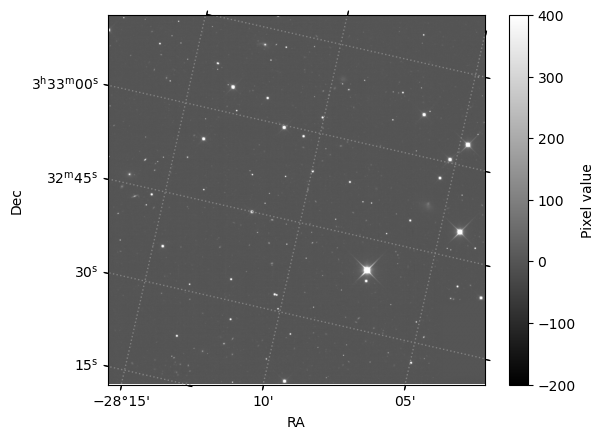

In [31]:
calexp_wcs = calexp.getWcs()   # other way: calexp_wcs = butler.get('calexp.wcs', **dataId)
fig = plt.figure()
ax = plt.subplot(projection=WCS(calexp_wcs.getFitsMetadata()))
im = plt.imshow(calexp.image.array, cmap='gray', vmin=-200.0, vmax=400,
                 origin='lower')
plt.colorbar(im, ax=ax, orientation='vertical', label='Pixel value')
plt.grid(color='gray', ls=':', lw=1)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
plt.show()


### 1. Settings and run

In [32]:
from lsst.pipe.tasks.characterizeImage import CharacterizeImageTask
char_calexp = calexp.clone()
config = CharacterizeImageTask.ConfigClass()
config.psfIterations = 3  # Increase for dense fields (e.g., blending studies)
config.doDeblend = True   # Essential for microlensing in crowded regions
config.detection.thresholdValue = 7.0  # Higher S/N for robust detection
config.measurement.doReplaceWithNoise = True
config.doWrite = True     # Persist for pipeline versatility
config.measurement.plugins.names.add('base_SkyCoord')
config.measurement.plugins.names.add('base_LocalBackground')  # fondo local (muy bueno en campos densos)

task = CharacterizeImageTask(config=config)
#calexp = butler.get('calexp', **dataId)  
result = task.run(char_calexp)  # Runs detection/measurement/PSF internally

In [33]:
result

Struct(exposure=<lsst.afw.image._exposure.ExposureF object at 0x7ddf441ac530>; sourceCat= id      coord_ra           coord_dec       ...  coord_decErr coord_ra_dec_Cov
           rad                 rad          ...      rad            rad2      
--- ------------------ -------------------- ... ------------- ----------------
  1 0.9262592766753247  -0.4919213920449998 ... 4.1039822e-08    -2.256055e-16
  2 0.9265608940849015  -0.4909717658303964 ... 3.2948563e-08    1.2515044e-17
  3 0.9264109076911968 -0.49138701203828494 ...           nan              nan
  4    0.9262759214349 -0.49238218245436993 ... 1.3183251e-07    2.0840418e-15
  5 0.9263364943316866  -0.4924120497624539 ... 1.3056551e-07   -3.7216934e-15
  6 0.9263285195513858 -0.49249688507877015 ...  1.202106e-07    8.7586335e-16
  7 0.9269588885531544 -0.49014012250068256 ... 3.2065954e-09   -4.2559034e-20
  8 0.9268590980041423 -0.49056105566707103 ...  3.196968e-08   1.29630055e-17
  9 0.9266200980582163  -0.491628354620271

### 2. Visualize result

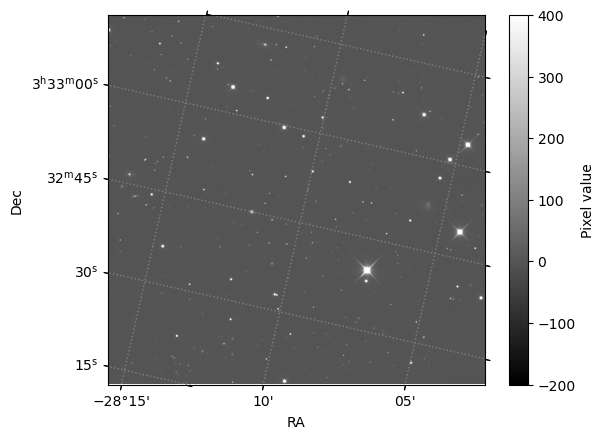

In [34]:
char_calexp = result.getDict()["characterized"]

char_calexp_wcs = calexp.getWcs()  
fig = plt.figure()
ax = plt.subplot(projection=WCS(char_calexp_wcs.getFitsMetadata()))

im = plt.imshow(char_calexp.image.array, cmap='gray', vmin=-200.0, vmax=400,
                 origin='lower')
plt.colorbar(im, ax=ax, orientation='vertical', label='Pixel value')

plt.grid(color='gray', ls=':', lw=1)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
plt.show()


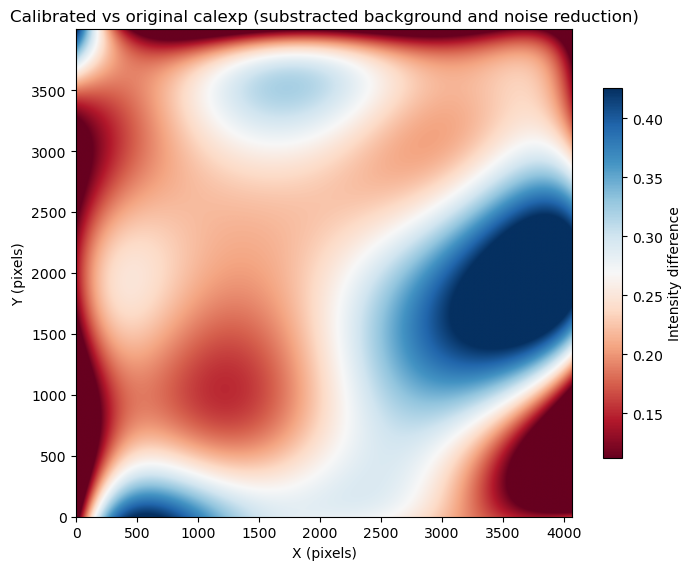

Mean difference: 0.25 (background)
Standar deviation difference: 0.09 (noise)


In [35]:
plot_pix_diff(calexp, char_calexp, "Calibrated vs original calexp (substracted background and noise reduction)" )

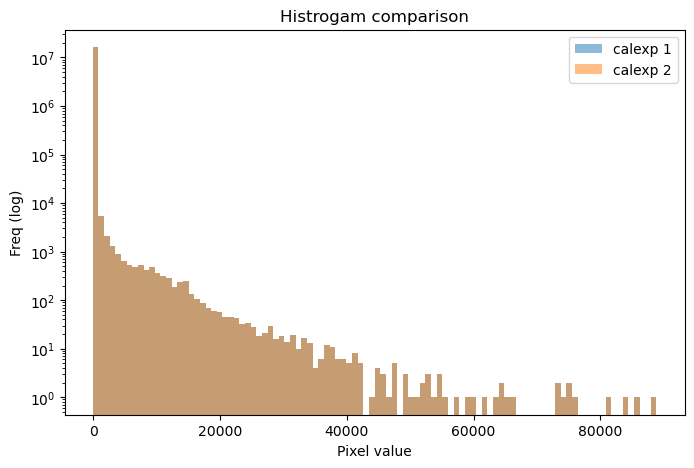

In [36]:
plot_hist_comparison(calexp, char_calexp)

In [37]:
position = geom.Point2D(calexp.width / 2, calexp.height / 2)
psf_before = calexp.getPsf()
sigma_before = psf_before.computeShape(position).getDeterminantRadius()

psf_after = char_calexp.getPsf()
sigma_after = psf_after.computeShape(position).getDeterminantRadius()

sigma_before, sigma_after, sigma_before-sigma_after

(2.768000581036253, 2.7683121119340792, -0.00031153089782609555)

## Injection Task
1) Load butler, injection task and sources (location and magnitudes) to inject
2) Create injection table
3) Run injection task
4) Visualize resutls: injected exposure and injected table

### 1) Settings
Load butler, injection task and sources (location and magnitudes) to inject

In [38]:
butler = Butler('dp02', collections='2.2i/runs/DP0.2')
source_data = results.iloc[150]
datasetType = 'calexp'
dataId = {'visit': source_data["visit"], 'detector': source_data["detector"]}
calexp = butler.get(datasetType, dataId=dataId)
calexp_wcs = calexp.getWcs()   # other way: calexp_wcs = butler.get('calexp.wcs', **dataId)


In [39]:
from lsst.source.injection import VisitInjectConfig, VisitInjectTask

inject_config = VisitInjectConfig()
injection_task = VisitInjectTask(config=inject_config)


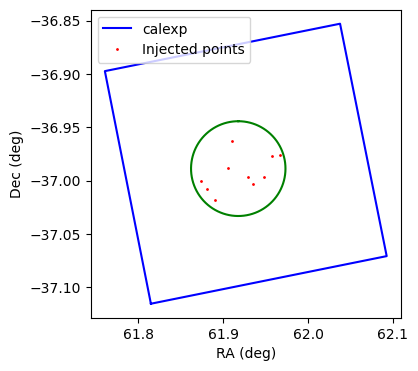

In [40]:
from shapely.geometry import Polygon, Point
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
np.random.seed(17)

def random_points_in_polygon(polygon, n):
    """Genera n puntos dentro del polígono."""
    xs, ys = [], []
    x0, y0, x1, y1 = polygon.bounds
    while len(xs) < n:
        x = np.random.uniform(x0, x1)
        y = np.random.uniform(y0, y1)
        if polygon.contains(Point(x, y)):
            xs.append(x); ys.append(y)
    return xs, ys

def random_points_in_sky_circle(center, radius, n):
    r = radius * np.sqrt(np.random.uniform(size=n))
    phi = 2 * np.pi * np.random.uniform(size=n)
    dra = (r * np.cos(phi)) / np.cos(center.getDec().asDegrees())
    ddec = r * np.sin(phi)
    return center.getRa().asDegrees() + dra, center.getDec().asDegrees() + ddec
    

    
calexp_wcs = calexp.getWcs()
sky_center =[coord.asDegrees() for coord in calexp_wcs.getSkyOrigin()]
radius = calexp.height * calexp_wcs.getPixelScale() *0.2

n_points = 10
ra_values, dec_values = random_points_in_sky_circle(calexp_wcs.getSkyOrigin(), 
                                                    radius=radius.asDegrees(), 
                                                    n=n_points)

fig, ax = plt.subplots(figsize=(4,4))
height, width = calexp.getDimensions()
corners_pix = [
    geom.Point2D(0, 0),
    geom.Point2D(width, 0),
    geom.Point2D(width, height),
    geom.Point2D(0, height)
]
corners_sky = [calexp_wcs.pixelToSky(p) for p in corners_pix]
corners_deg = [(c.getRa().asDegrees(), c.getDec().asDegrees()) for c in corners_sky]

poly = Polygon(corners_deg)

x, y = poly.exterior.xy
ax.plot(x, y, color="blue",  label="calexp")

sky_center = SkyCoord(ra=sky_center[0]*u.deg, dec=sky_center[1]*u.deg)
radius_astropy = radius.asDegrees() * u.deg
circ = sky_center.directional_offset_by(
            position_angle=np.linspace(0, 360, 400) * u.deg,
            separation=radius_astropy
       )
ax.plot(circ.ra.deg, circ.dec.deg, color='green')

ax.plot(ra_values, dec_values, "o", ms=1, color="red", label = "Injected points")

ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.legend()



### 2) Create injection table
The input is an astropy Table of sources which needs minimal data columns: magnitudes, source type and coordinates, but any other column can be added to maintain sources index correlation, or just add an "injection_id" column keep track of the sources results.

In [41]:
from astropy.table import Table

injection_id = list(range(n_points))  
mag = np.linspace(16, 26, n_points)
source_type = ["Star"] * n_points
data = [injection_id, ra_values, dec_values, source_type, mag]

inject_table = Table(data, names=['injection_id', 'ra', 'dec', 'source_type', 'mag'])
inject_table

injection_id,ra,dec,source_type,mag
int64,float64,float64,str4,float64
0,61.94780794046796,-36.99676111018982,Star,16.0
1,61.9575100050956,-36.97678133306728,Star,17.11111111111111
2,61.93468389361193,-37.00334634472838,Star,18.22222222222222
3,61.92879570575899,-36.996756749056544,Star,19.333333333333332
4,61.96714022835633,-36.976243295245084,Star,20.444444444444443
5,61.89054903000857,-37.01811176353185,Star,21.555555555555557
6,61.873539829935886,-37.00001954234831,Star,22.666666666666668
7,61.88150042075004,-37.008065437363136,Star,23.77777777777778
8,61.90633755916403,-36.98778831551789,Star,24.88888888888889


### 3) Run injection task

In [42]:
injected_output = injection_task.run(
                    injection_catalogs=[inject_table],
                    input_exposure=calexp.clone(),
                    psf=calexp.getPsf(),
                    photo_calib=calexp.getPhotoCalib(),
                    wcs=calexp.wcs)
injected_exposure = injected_output.output_exposure
injected_catalog = injected_output.output_catalog

### 4) Visualize results
injected exposure and injected table

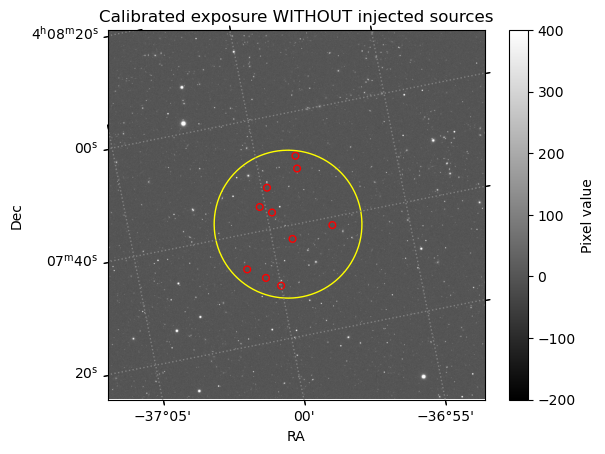

In [43]:
fig = plt.figure()
ax = plt.subplot(projection=WCS(calexp_wcs.getFitsMetadata()))

im = plt.imshow(calexp.image.array, cmap='gray', vmin=-200.0, vmax=400,
                 origin='lower')
plt.colorbar(im, ax=ax, orientation='vertical', label='Pixel value')
for ra, dec in zip(ra_values, dec_values):
    region = SphericalCircle((ra, dec) * u.deg, 0.002 * u.deg, edgecolor='red', facecolor='none', transform=ax.get_transform('world') )
    plt.gca().add_patch(region)
region = SphericalCircle((sky_center.ra.value, sky_center.dec.value) * u.deg,radius.asDegrees() * u.deg, edgecolor='yellow', facecolor='none', transform=ax.get_transform('world') )
plt.gca().add_patch(region)
plt.title("Calibrated exposure WITHOUT injected sources")
plt.grid(color='gray', ls=':', lw=1)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
plt.show()

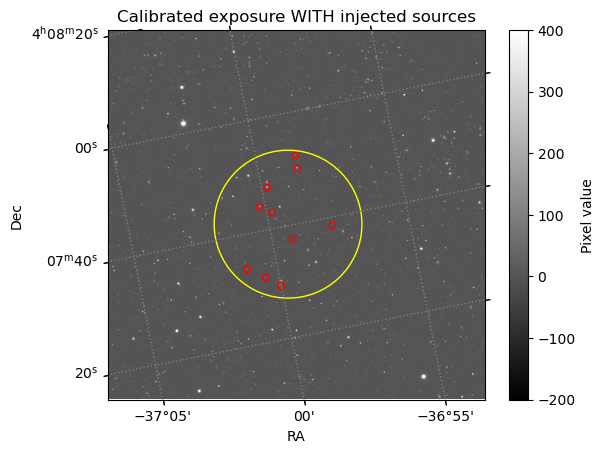

In [44]:
injected_exposure_wcs = injected_exposure.getWcs()   # other way: calexp_wcs = butler.get('calexp.wcs', **dataId)
fig = plt.figure()
ax = plt.subplot(projection=WCS(injected_exposure_wcs.getFitsMetadata()))

im = plt.imshow(injected_exposure.image.array, cmap='gray', vmin=-200.0, vmax=400,
                 origin='lower')
plt.colorbar(im, ax=ax, orientation='vertical', label='Pixel value')

for ra, dec in zip(ra_values, dec_values):
    region = SphericalCircle((ra, dec) * u.deg, 0.002 * u.deg, edgecolor='red', facecolor='none', transform=ax.get_transform('world') )
    plt.gca().add_patch(region)
region = SphericalCircle((sky_center.ra.value, sky_center.dec.value) * u.deg,radius.asDegrees() * u.deg, edgecolor='yellow', facecolor='none', transform=ax.get_transform('world') )
plt.gca().add_patch(region)

plt.title("Calibrated exposure WITH injected sources")
plt.grid(color='gray', ls=':', lw=1)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
plt.show()

Text(0.5, 1.0, 'Cutout of calibrated exposure WITH injected sources')

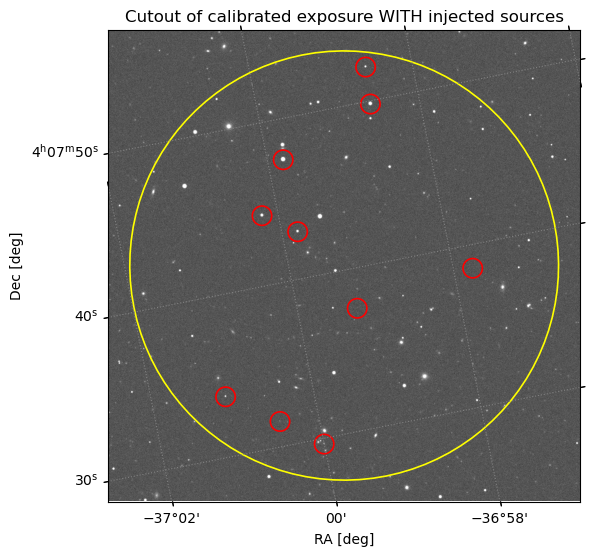

In [45]:

circles = [
    {"ra": sky_center.ra.value, "dec": sky_center.dec.value, "r": radius.asDegrees(), "color": "yellow"},
]

for ra, dec in zip(ra_values, dec_values):
    circles.append({"ra": ra, "dec": dec, "r": 0.002, "color": "red"})

plot_calexp_cutout(
    injected_exposure,
    center_ra=sky_center.ra.value,
    center_dec=sky_center.dec.value,
    radius_deg=radius.asDegrees(),
    circles=circles
)
plt.title("Cutout of calibrated exposure WITH injected sources")

## Forced Measurement Task

In [46]:
import lsst.afw.table as afwTable
from lsst.meas.base import ForcedMeasurementTask

schema = afwTable.SourceTable.makeMinimalSchema()
alias = schema.getAliasMap() 
x_key = schema.addField("centroid_x", type="D")
y_key = schema.addField("centroid_y", type="D")
alias.set("slot_Centroid", "centroid")

xx_key = schema.addField("shape_xx", type="D")
yy_key = schema.addField("shape_yy", type="D")
xy_key = schema.addField("shape_xy", type="D")
alias.set("slot_Shape", "shape")
type_key = schema.addField("type_flag", type="F")
config = ForcedMeasurementTask.ConfigClass()
config.copyColumns = {}
config.plugins.names = [
    "base_TransformedCentroid",
    "base_PsfFlux",
    "base_TransformedShape"
]
config.doReplaceWithNoise = False
forcedMeasurementTask = ForcedMeasurementTask(schema, config=config)
del config

In [47]:
def pix_to_sky(exposure, x, y):
    """Convert pixel coordinates to RA and Dec."""
    sphere_point = exposure.wcs.pixelToSky(geom.Point2D(x, y))
    return sphere_point.getRa().asDegrees(), sphere_point.getDec().asDegrees()

def sky_to_pix(exposure, ra, dec):
    """Convert RA and Dec to pixel coordinates."""
    xy = exposure.wcs.skyToPixel(geom.SpherePoint(ra * geom.degrees, dec * geom.degrees))
    return int(np.round(xy.getX())), int(np.round(xy.getY()))

def flux_to_mag(exposure, flux, flux_err):
    photoCalib = exposure.getPhotoCalib()
    measure = photoCalib.instFluxToMagnitude(flux, flux_err)
    return measure.value, measure.error

In [48]:
ra_inj = injected_catalog["ra"]; dec_inj =  injected_catalog["dec"]
forcedSource = afwTable.SourceCatalog(schema)
for source in injected_catalog:
    sourceRec = forcedSource.addNew()
    coord = geom.SpherePoint(geom.Angle(source["ra"], geom.degrees).asRadians(),geom.Angle(source["dec"], geom.degrees).asRadians(), geom.radians)
    sourceRec.setCoord(coord)
    sourceRec[x_key], sourceRec[y_key]= sky_to_pix(injected_exposure, source["ra"], source["dec"])
    sourceRec[type_key] = 0
del sourceRec, coord
forcedSource[0]

<class 'lsst.afw.table.SourceRecord'>
id: 1
coord_ra: 1.08119 rad
coord_dec: -0.645715 rad
parent: 0
centroid_x: 1717
centroid_y: 2291
shape_xx: nan
shape_yy: nan
shape_xy: nan
type_flag: 0

In [49]:

forcedMeasCat = forcedMeasurementTask.generateMeasCat(
    injected_exposure, forcedSource, injected_exposure.getWcs()
)
forcedMeasurementTask.run(
    forcedMeasCat, injected_exposure, forcedSource, injected_exposure.getWcs()
)

tab = forcedMeasCat.asAstropy()
tab["coord_ra"] = injected_catalog["ra"]
tab["coord_dec"] = injected_catalog["dec"]
tab["injection_id"] = injected_catalog["injection_id"]
tab["inj_mag"] = injected_catalog["mag"]

flux     = tab["base_PsfFlux_instFlux"].value
flux_err = tab["base_PsfFlux_instFluxErr"].value

m, m_err = zip(*(flux_to_mag(injected_exposure, f, e) for f, e in zip(flux, flux_err)))
tab["mag"] = m
tab["mag_err"] = m_err

tab


id,coord_ra,coord_dec,parent,base_TransformedCentroid_x,slot_Centroid_x,base_TransformedCentroid_y,slot_Centroid_y,base_TransformedShape_xx,slot_Shape_xx,base_TransformedShape_yy,slot_Shape_yy,base_TransformedShape_xy,slot_Shape_xy,base_PsfFlux_instFlux,base_PsfFlux_instFluxErr,base_PsfFlux_area,base_PsfFlux_chi2,base_PsfFlux_npixels,base_PsfFlux_flag,base_PsfFlux_flag_noGoodPixels,base_PsfFlux_flag_edge,base_InvalidPsf_flag,injection_id,inj_mag,mag,mag_err
,,,,pix,pix,pix,pix,pix2,pix2,pix2,pix2,pix2,pix2,ct,ct,pix,,pix,,,,,,,,
int64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,int32,bool,bool,bool,bool,int64,float64,float64,float64
1,61.94780794046796,-36.99676111018982,0,1717.0,1717.0,2291.0,2291.0,nan,nan,nan,nan,nan,nan,2885344.9941435065,2418.535010195169,30.171293,157754.7,1681,False,False,False,False,0,16.0,16.026811428251733,0.0009100787005969257
2,61.9575100050956,-36.97678133306728,0,2042.0,2042.0,2499.0,2499.0,nan,nan,nan,nan,nan,nan,1036196.5608730641,1460.3302593115013,30.150505,57038.73,1681,False,False,False,False,1,17.11111111111111,17.138700432418116,0.0015301473613292132
3,61.93468389361193,-37.00334634472838,0,1638.0,1638.0,2083.0,2083.0,nan,nan,nan,nan,nan,nan,379185.483711758,904.3096079953335,30.1782,6866.0854,1681,False,False,False,False,2,18.22222222222222,18.230176541332376,0.0025893440648100414
4,61.92879570575899,-36.996756749056544,0,1771.0,1771.0,2023.0,2023.0,nan,nan,nan,nan,nan,nan,136130.38950021012,570.8404075021904,30.163816,2593.3948,1681,False,False,False,False,3,19.333333333333332,19.342418080914104,0.004552856271398941
5,61.96714022835633,-36.976243295245084,0,2025.0,2025.0,2637.0,2637.0,nan,nan,nan,nan,nan,nan,48759.8715312082,385.0252200822244,30.15343,2608.225,1681,False,False,False,False,4,20.444444444444443,20.457149416998632,0.008573357723485362
6,61.89054903000857,-37.01811176353185,0,1502.0,1502.0,1408.0,1408.0,nan,nan,nan,nan,nan,nan,16526.260939622887,287.8494746964641,30.197432,2116.7263,1681,False,False,False,False,5,21.555555555555557,21.631869284451643,0.01891102877658494
7,61.873539829935886,-37.00001954234831,0,1870.0,1870.0,1231.0,1231.0,nan,nan,nan,nan,nan,nan,6217.616180772403,249.5487887095139,30.163023,3283.336,1681,False,False,False,False,6,22.666666666666668,22.6932460259221,0.043576854356712165
8,61.88150042075004,-37.008065437363136,0,1705.0,1705.0,1315.0,1315.0,nan,nan,nan,nan,nan,nan,2318.600401955662,234.32208981525704,30.174463,1800.7303,1681,False,False,False,False,7,23.77777777777778,23.764241031707037,0.10972652996713995


Text(0, 0.5, '$mag_{inj}-mag_{meas}$')

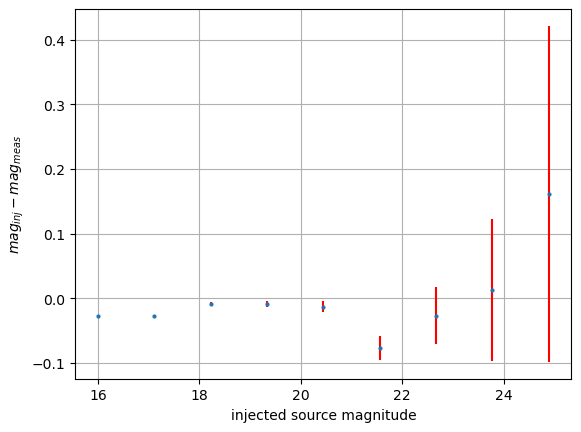

In [50]:
plt.errorbar(tab["inj_mag"], tab["inj_mag"]-tab["mag"], yerr=abs(tab["mag_err"]), marker="o", markersize=2, linestyle="", ecolor="red")
plt.grid()
plt.xlabel("injected source magnitude")
plt.ylabel("$mag_{inj}-mag_{meas}$")

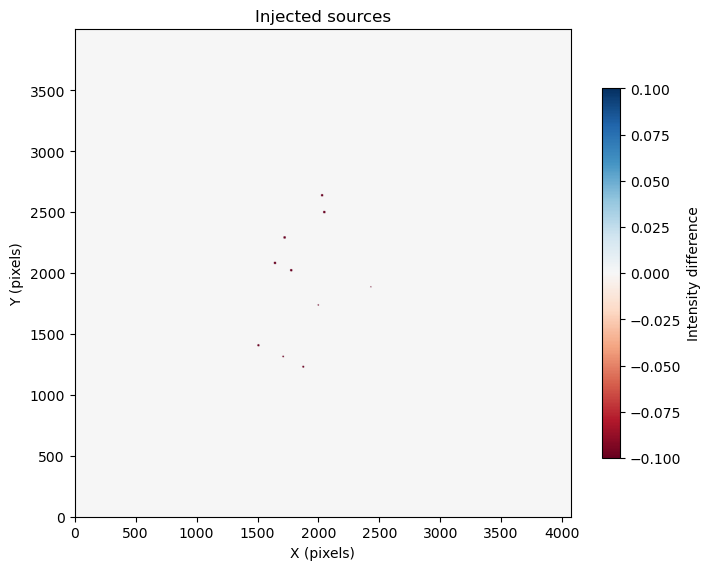

Mean difference: -0.28 (background)
Standar deviation difference: 142.86 (noise)


In [51]:
plot_pix_diff(calexp, injected_exposure, "Injected sources")

## Source Detection Task

In [52]:
import lsst.daf.base as dafBase
import lsst.afw.table as afwTable
from lsst.meas.base import ForcedMeasurementTask
from astropy.table import Table
from shapely.geometry import Polygon, Point
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
from lsst.source.injection import VisitInjectConfig, VisitInjectTask
from lsst.pipe.tasks.characterizeImage import CharacterizeImageTask
from lsst.meas.algorithms.detection import SourceDetectionTask
from lsst.meas.deblender import SourceDeblendTask
from lsst.meas.base import SingleFrameMeasurementTask
from lsst.meas.base import ForcedMeasurementTask

# Load calexp
butler = Butler('dp02', collections='2.2i/runs/DP0.2')
source_data = results.iloc[150]
datasetType = 'calexp'
dataId = {'visit': source_data["visit"], 'detector': source_data["detector"]}
calexp = butler.get(datasetType, dataId=dataId)
calexp_wcs = calexp.getWcs() 


### 1. Task configurations


In [53]:
schema = afwTable.SourceTable.makeMinimalSchema()
tab = afwTable.SourceTable.make(schema)
raerr = schema.addField("coord_raErr", type="F")
decerr = schema.addField("coord_decErr", type="F")
algMetadata = dafBase.PropertyList()
config = CharacterizeImageTask.ConfigClass()
config.psfIterations = 1
charImageTask = CharacterizeImageTask(config=config)
del config
config = SourceDetectionTask.ConfigClass()
config.thresholdValue = 4
config.thresholdType = "stdev"
sourceDetectionTask = SourceDetectionTask(schema=schema, config=config)
del config
sourceDeblendTask = SourceDeblendTask(schema=schema)
config = SingleFrameMeasurementTask.ConfigClass()
sourceMeasurementTask = SingleFrameMeasurementTask(schema=schema,
                                                   config=config,
                                                   algMetadata=algMetadata)
del config
tab = afwTable.SourceTable.make(schema)
del schema

### 2. Run tasks

#### characterization + detection

In [54]:
result = charImageTask.run(calexp)
result = sourceDetectionTask.run(tab, calexp)

In [55]:
result.numPosPeaks
sources = result.sources

In [56]:
for k, v in result.getDict().items():
    print(k, type(v))

positive <class 'lsst.afw.detection.FootprintSet'>
negative <class 'NoneType'>
factor <class 'float'>
factorNeg <class 'float'>
positiveThreshold <class 'lsst.afw.detection.Threshold'>
negativeThreshold <class 'lsst.afw.detection.Threshold'>
background <class 'lsst.afw.math._backgroundList.BackgroundList'>
numPos <class 'int'>
numPosPeaks <class 'int'>
numNeg <class 'int'>
numNegPeaks <class 'int'>
sources <class 'lsst.afw.table.SourceCatalog'>


#### deblend + measurement 

In [57]:
sourceDeblendTask.run(calexp, sources)
sourceMeasurementTask.run(measCat=sources, exposure=calexp)

In [58]:
sources = sources.copy(True)
sources.asAstropy()

id,coord_ra,coord_dec,parent,coord_raErr,coord_decErr,deblend_nChild,deblend_deblendedAsPsf,deblend_psfCenter_x,deblend_psfCenter_y,deblend_psf_instFlux,deblend_tooManyPeaks,deblend_parentTooBig,deblend_masked,deblend_failed,deblend_skipped,deblend_rampedTemplate,deblend_patchedTemplate,deblend_hasStrayFlux,deblend_peak_center_x,deblend_peak_center_y,deblend_peakId,deblend_nPeaks,deblend_parentNPeaks,base_SdssCentroid_x,slot_Centroid_x,base_SdssCentroid_y,slot_Centroid_y,base_SdssCentroid_xErr,slot_Centroid_xErr,base_SdssCentroid_yErr,slot_Centroid_yErr,base_SdssCentroid_flag,base_CircularApertureFlux_flag_badCentroid,base_GaussianFlux_flag_badCentroid,base_LocalBackground_flag_badCentroid,base_PsfFlux_flag_badCentroid,base_SdssShape_flag_badCentroid,base_Variance_flag_badCentroid,slot_Centroid_flag,base_SdssCentroid_flag_edge,base_CircularApertureFlux_flag_badCentroid_edge,base_GaussianFlux_flag_badCentroid_edge,base_LocalBackground_flag_badCentroid_edge,base_PsfFlux_flag_badCentroid_edge,base_SdssShape_flag_badCentroid_edge,base_Variance_flag_badCentroid_edge,slot_Centroid_flag_edge,base_SdssCentroid_flag_noSecondDerivative,base_CircularApertureFlux_flag_badCentroid_noSecondDerivative,base_GaussianFlux_flag_badCentroid_noSecondDerivative,base_LocalBackground_flag_badCentroid_noSecondDerivative,base_PsfFlux_flag_badCentroid_noSecondDerivative,base_SdssShape_flag_badCentroid_noSecondDerivative,base_Variance_flag_badCentroid_noSecondDerivative,slot_Centroid_flag_noSecondDerivative,base_SdssCentroid_flag_almostNoSecondDerivative,base_CircularApertureFlux_flag_badCentroid_almostNoSecondDerivative,base_GaussianFlux_flag_badCentroid_almostNoSecondDerivative,base_LocalBackground_flag_badCentroid_almostNoSecondDerivative,base_PsfFlux_flag_badCentroid_almostNoSecondDerivative,base_SdssShape_flag_badCentroid_almostNoSecondDerivative,base_Variance_flag_badCentroid_almostNoSecondDerivative,slot_Centroid_flag_almostNoSecondDerivative,base_SdssCentroid_flag_notAtMaximum,base_CircularApertureFlux_flag_badCentroid_notAtMaximum,base_GaussianFlux_flag_badCentroid_notAtMaximum,base_LocalBackground_flag_badCentroid_notAtMaximum,base_PsfFlux_flag_badCentroid_notAtMaximum,base_SdssShape_flag_badCentroid_notAtMaximum,base_Variance_flag_badCentroid_notAtMaximum,slot_Centroid_flag_notAtMaximum,base_SdssCentroid_flag_near_edge,base_CircularApertureFlux_flag_badCentroid_near_edge,base_GaussianFlux_flag_badCentroid_near_edge,base_LocalBackground_flag_badCentroid_near_edge,base_PsfFlux_flag_badCentroid_near_edge,base_SdssShape_flag_badCentroid_near_edge,base_Variance_flag_badCentroid_near_edge,slot_Centroid_flag_near_edge,base_SdssCentroid_flag_resetToPeak,base_CircularApertureFlux_flag_badCentroid_resetToPeak,base_GaussianFlux_flag_badCentroid_resetToPeak,base_LocalBackground_flag_badCentroid_resetToPeak,base_PsfFlux_flag_badCentroid_resetToPeak,base_SdssShape_flag_badCentroid_resetToPeak,base_Variance_flag_badCentroid_resetToPeak,slot_Centroid_flag_resetToPeak,base_SdssCentroid_flag_badError,base_CircularApertureFlux_flag_badCentroid_badError,base_GaussianFlux_flag_badCentroid_badError,base_LocalBackground_flag_badCentroid_badError,base_PsfFlux_flag_badCentroid_badError,base_SdssShape_flag_badCentroid_badError,base_Variance_flag_badCentroid_badError,slot_Centroid_flag_badError,base_Blendedness_old,base_Blendedness_raw,base_Blendedness_raw_child_instFlux,base_Blendedness_raw_parent_instFlux,base_Blendedness_abs,base_Blendedness_abs_child_instFlux,base_Blendedness_abs_parent_instFlux,base_Blendedness_raw_child_xx,base_Blendedness_raw_child_yy,base_Blendedness_raw_child_xy,base_Blendedness_raw_parent_xx,base_Blendedness_raw_parent_yy,base_Blendedness_raw_parent_xy,base_Blendedness_abs_child_xx,base_Blendedness_abs_child_yy,base_Blendedness_abs_child_xy,base_Blendedness_abs_parent_xx,base_Blendedness_abs_parent_yy,base_Blendedness_abs_parent_xy,base_Blendedness_flag,base_Blendedness_flag_noCentroid,base_Blendedness_flag_noShape,base_SdssShape_xx,slot_Shape

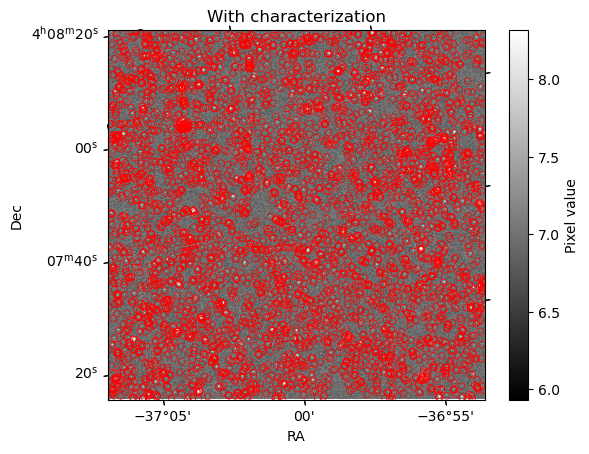

In [59]:
from astropy.visualization import ZScaleInterval

fig = plt.figure()
wcs = calexp.getWcs()
ax = fig.add_subplot(projection=WCS(wcs.getFitsMetadata()))

img = calexp.image.array
interval = ZScaleInterval(contrast=50)
vmin, vmax = interval.get_limits(img)
im = ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar(im, ax=ax, label='Pixel value')

tab = sources.asAstropy()
for ra, dec in zip(tab["coord_ra"].to(u.deg), tab["coord_dec"].to(u.deg)):
    circ = SphericalCircle((ra, dec) * u.deg, 0.002*u.deg,
                           edgecolor='red', facecolor='none',
                           lw=0.5, transform=ax.get_transform('world'))
    ax.add_patch(circ)

ax.set(title="With characterization", xlabel="RA", ylabel="Dec")
ax.grid(color='gray', ls=':', lw=1)

plt.show()


### 3. Comparison without characterization

In [60]:
# Load calexp
butler = Butler('dp02', collections='2.2i/runs/DP0.2')
source_data = results.iloc[150]
datasetType = 'calexp'
dataId = {'visit': source_data["visit"], 'detector': source_data["detector"]}
calexp = butler.get(datasetType, dataId=dataId)
calexp_wcs = calexp.getWcs() 


In [61]:
schema = afwTable.SourceTable.makeMinimalSchema()
tab = afwTable.SourceTable.make(schema)
raerr = schema.addField("coord_raErr", type="F")
decerr = schema.addField("coord_decErr", type="F")
algMetadata = dafBase.PropertyList()
config = CharacterizeImageTask.ConfigClass()
config.psfIterations = 1
charImageTask = CharacterizeImageTask(config=config)
del config
config = SourceDetectionTask.ConfigClass()
config.thresholdValue = 4
config.thresholdType = "stdev"
sourceDetectionTask = SourceDetectionTask(schema=schema, config=config)
del config
sourceDeblendTask = SourceDeblendTask(schema=schema)
config = SingleFrameMeasurementTask.ConfigClass()
sourceMeasurementTask = SingleFrameMeasurementTask(schema=schema,
                                                   config=config,
                                                   algMetadata=algMetadata)
del config
tab = afwTable.SourceTable.make(schema)
del schema

In [62]:
result = sourceDetectionTask.run(tab, calexp)
result.numPosPeaks
sources = result.sources
sourceDeblendTask.run(calexp, sources)
sourceMeasurementTask.run(measCat=sources, exposure=calexp)
sources = sources.copy(True)
sources.asAstropy()

id,coord_ra,coord_dec,parent,coord_raErr,coord_decErr,deblend_nChild,deblend_deblendedAsPsf,deblend_psfCenter_x,deblend_psfCenter_y,deblend_psf_instFlux,deblend_tooManyPeaks,deblend_parentTooBig,deblend_masked,deblend_failed,deblend_skipped,deblend_rampedTemplate,deblend_patchedTemplate,deblend_hasStrayFlux,deblend_peak_center_x,deblend_peak_center_y,deblend_peakId,deblend_nPeaks,deblend_parentNPeaks,base_SdssCentroid_x,slot_Centroid_x,base_SdssCentroid_y,slot_Centroid_y,base_SdssCentroid_xErr,slot_Centroid_xErr,base_SdssCentroid_yErr,slot_Centroid_yErr,base_SdssCentroid_flag,base_CircularApertureFlux_flag_badCentroid,base_GaussianFlux_flag_badCentroid,base_LocalBackground_flag_badCentroid,base_PsfFlux_flag_badCentroid,base_SdssShape_flag_badCentroid,base_Variance_flag_badCentroid,slot_Centroid_flag,base_SdssCentroid_flag_edge,base_CircularApertureFlux_flag_badCentroid_edge,base_GaussianFlux_flag_badCentroid_edge,base_LocalBackground_flag_badCentroid_edge,base_PsfFlux_flag_badCentroid_edge,base_SdssShape_flag_badCentroid_edge,base_Variance_flag_badCentroid_edge,slot_Centroid_flag_edge,base_SdssCentroid_flag_noSecondDerivative,base_CircularApertureFlux_flag_badCentroid_noSecondDerivative,base_GaussianFlux_flag_badCentroid_noSecondDerivative,base_LocalBackground_flag_badCentroid_noSecondDerivative,base_PsfFlux_flag_badCentroid_noSecondDerivative,base_SdssShape_flag_badCentroid_noSecondDerivative,base_Variance_flag_badCentroid_noSecondDerivative,slot_Centroid_flag_noSecondDerivative,base_SdssCentroid_flag_almostNoSecondDerivative,base_CircularApertureFlux_flag_badCentroid_almostNoSecondDerivative,base_GaussianFlux_flag_badCentroid_almostNoSecondDerivative,base_LocalBackground_flag_badCentroid_almostNoSecondDerivative,base_PsfFlux_flag_badCentroid_almostNoSecondDerivative,base_SdssShape_flag_badCentroid_almostNoSecondDerivative,base_Variance_flag_badCentroid_almostNoSecondDerivative,slot_Centroid_flag_almostNoSecondDerivative,base_SdssCentroid_flag_notAtMaximum,base_CircularApertureFlux_flag_badCentroid_notAtMaximum,base_GaussianFlux_flag_badCentroid_notAtMaximum,base_LocalBackground_flag_badCentroid_notAtMaximum,base_PsfFlux_flag_badCentroid_notAtMaximum,base_SdssShape_flag_badCentroid_notAtMaximum,base_Variance_flag_badCentroid_notAtMaximum,slot_Centroid_flag_notAtMaximum,base_SdssCentroid_flag_near_edge,base_CircularApertureFlux_flag_badCentroid_near_edge,base_GaussianFlux_flag_badCentroid_near_edge,base_LocalBackground_flag_badCentroid_near_edge,base_PsfFlux_flag_badCentroid_near_edge,base_SdssShape_flag_badCentroid_near_edge,base_Variance_flag_badCentroid_near_edge,slot_Centroid_flag_near_edge,base_SdssCentroid_flag_resetToPeak,base_CircularApertureFlux_flag_badCentroid_resetToPeak,base_GaussianFlux_flag_badCentroid_resetToPeak,base_LocalBackground_flag_badCentroid_resetToPeak,base_PsfFlux_flag_badCentroid_resetToPeak,base_SdssShape_flag_badCentroid_resetToPeak,base_Variance_flag_badCentroid_resetToPeak,slot_Centroid_flag_resetToPeak,base_SdssCentroid_flag_badError,base_CircularApertureFlux_flag_badCentroid_badError,base_GaussianFlux_flag_badCentroid_badError,base_LocalBackground_flag_badCentroid_badError,base_PsfFlux_flag_badCentroid_badError,base_SdssShape_flag_badCentroid_badError,base_Variance_flag_badCentroid_badError,slot_Centroid_flag_badError,base_Blendedness_old,base_Blendedness_raw,base_Blendedness_raw_child_instFlux,base_Blendedness_raw_parent_instFlux,base_Blendedness_abs,base_Blendedness_abs_child_instFlux,base_Blendedness_abs_parent_instFlux,base_Blendedness_raw_child_xx,base_Blendedness_raw_child_yy,base_Blendedness_raw_child_xy,base_Blendedness_raw_parent_xx,base_Blendedness_raw_parent_yy,base_Blendedness_raw_parent_xy,base_Blendedness_abs_child_xx,base_Blendedness_abs_child_yy,base_Blendedness_abs_child_xy,base_Blendedness_abs_parent_xx,base_Blendedness_abs_parent_yy,base_Blendedness_abs_parent_xy,base_Blendedness_flag,base_Blendedness_flag_noCentroid,base_Blendedness_flag_noShape,base_SdssShape_xx,slot_Shape

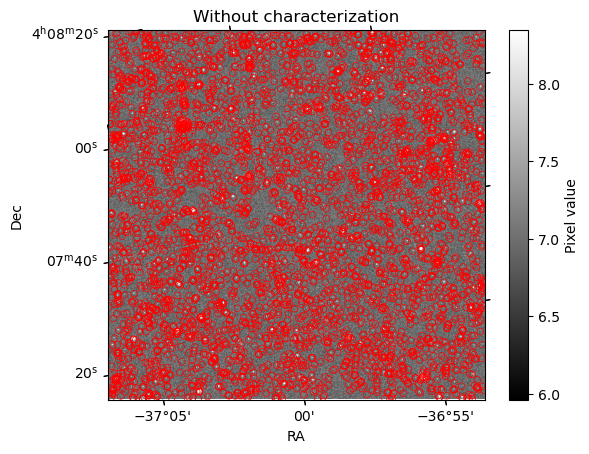

In [63]:
from astropy.visualization import ZScaleInterval

fig = plt.figure()
wcs = calexp.getWcs()
ax = fig.add_subplot(projection=WCS(wcs.getFitsMetadata()))

img = calexp.image.array
interval = ZScaleInterval(contrast=50)
vmin, vmax = interval.get_limits(img)
im = ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar(im, ax=ax, label='Pixel value')

tab = sources.asAstropy()
for ra, dec in zip(tab["coord_ra"].to(u.deg), tab["coord_dec"].to(u.deg)):
    circ = SphericalCircle((ra, dec) * u.deg, 0.002*u.deg,
                           edgecolor='red', facecolor='none',
                           lw=0.5, transform=ax.get_transform('world'))
    ax.add_patch(circ)

ax.set(title="Without characterization", xlabel="RA", ylabel="Dec")
ax.grid(color='gray', ls=':', lw=1)

plt.show()
